In [1]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

plt.style.use('fivethirtyeight')

In [4]:
end = datetime.now()
start = datetime(end.year-15, end.month, end.day)

stock = 'GC=F'   # Gold Futures

stock_data = yf.download(stock, start=start, end=end)

C:\Users\Soham Rajapurkar\AppData\Local\Temp\ipykernel_9424\3304298756.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(stock, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


In [5]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2011-03-11,1421.500000,1422.599976,1404.900024,1413.699951,23
2011-03-14,1424.599976,1427.699951,1420.000000,1420.000000,58
2011-03-15,1392.599976,1413.300049,1385.500000,1413.300049,20
2011-03-16,1396.000000,1404.199951,1394.300049,1398.000000,38
2011-03-17,1404.000000,1393.599976,1387.699951,1387.699951,27


In [9]:
stock_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
count,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000
mean,1737.423308,1746.865845,1727.699125,1737.372581,5187.847786
std,691.874350,698.398116,685.166024,691.868508,27904.942211
min,1050.800049,1062.000000,1046.199951,1053.699951,0.000000
25%,1281.350037,1286.200012,1276.900024,1281.450012,49.000000
50%,1592.300049,1603.300049,1583.000000,1592.900024,188.000000
75%,1866.199951,1874.100037,1856.300049,1867.000000,600.500000
max,5318.399902,5586.200195,5301.600098,5415.700195,386334.000000


In [16]:
stock_data.describe().T

,,count,mean,std,min,25%,50%,75%,max
Price,Ticker,,,,,,,,
Close,GC=F,3771.0,1737.423308,691.874350,1050.800049,1281.350037,1592.300049,1866.199951,5318.399902
High,GC=F,3771.0,1746.865845,698.398116,1062.000000,1286.200012,1603.300049,1874.100037,5586.200195
Low,GC=F,3771.0,1727.699125,685.166024,1046.199951,1276.900024,1583.000000,1856.300049,5301.600098
Open,GC=F,3771.0,1737.372581,691.868508,1053.699951,1281.450012,1592.900024,1867.000000,5415.700195
Volume,GC=F,3771.0,5187.847786,27904.942211,0.000000,49.000000,188.000000,600.500000,386334.000000


In [18]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3771 entries, 2011-03-11 to 2026-03-11
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GC=F)   3771 non-null   float64
 1   (High, GC=F)    3771 non-null   float64
 2   (Low, GC=F)     3771 non-null   float64
 3   (Open, GC=F)    3771 non-null   float64
 4   (Volume, GC=F)  3771 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 176.8 KB


In [20]:
stock_data.columns

MultiIndex([( 'Close', 'GC=F'),
            (  'High', 'GC=F'),
            (   'Low', 'GC=F'),
            (  'Open', 'GC=F'),
            ('Volume', 'GC=F')],
           names=['Price', 'Ticker'])

In [22]:
closing_price = stock_data[['Close']]

In [24]:
closing_price["Close"]

Ticker,GC=F
Date,
2011-03-11,1421.500000
2011-03-14,1424.599976
2011-03-15,1392.599976
2011-03-16,1396.000000
2011-03-17,1404.000000
...,...
2026-03-05,5065.299805
2026-03-06,5146.100098
2026-03-09,5091.500000


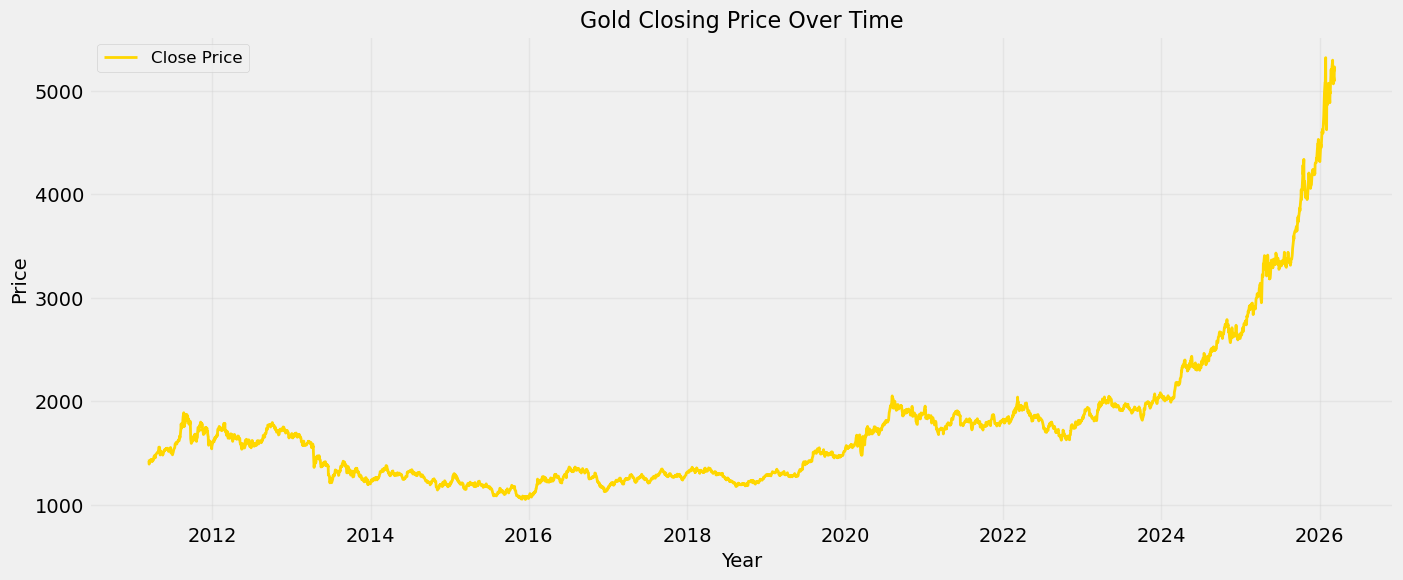

In [26]:
plt.figure(figsize=(15,6))
plt.plot(closing_price.index, closing_price['Close'], label='Close Price', color='gold', linewidth=2)

plt.title("Gold Closing Price Over Time", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Price", fontsize=14)

plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

In [33]:
closing_price['MA_365'] = closing_price['Close'].rolling(window=365).mean()
closing_price['MA_100'] = closing_price['Close'].rolling(window=100).mean()

C:\Users\Soham Rajapurkar\AppData\Local\Temp\ipykernel_9424\2942381381.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_365'] = closing_price['Close'].rolling(window=365).mean()
C:\Users\Soham Rajapurkar\AppData\Local\Temp\ipykernel_9424\2942381381.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_100'] = closing_price['Close'].rolling(window=100).mean()


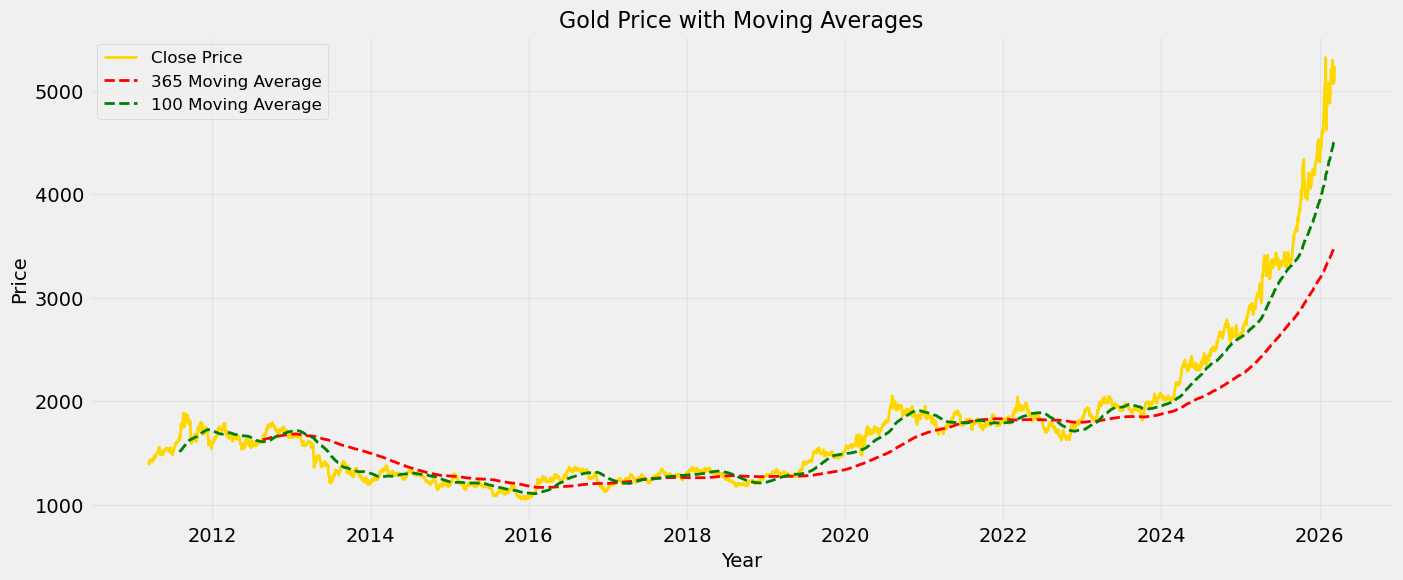

In [35]:
plt.figure(figsize=(15,6))

plt.plot(closing_price.index, closing_price['Close'], label='Close Price', color='gold', linewidth=2)
plt.plot(closing_price.index, closing_price['MA_365'], label='365 Moving Average', color='red', linestyle="--", linewidth=2)
plt.plot(closing_price.index, closing_price['MA_100'], label='100 Moving Average', color='green', linestyle="--", linewidth=2)

plt.title("Gold Price with Moving Averages", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Price", fontsize=14)

plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

In [37]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(closing_price[['Close']].dropna())

In [39]:
len(scaled_data)

3771

In [41]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [42]:
x_data = []
y_data = []

base_days = 100

for i in range(base_days, len(scaled_data)):
    x_data.append(scaled_data[i-base_days:i])
    y_data.append(scaled_data[i])

x_data = np.array(x_data)
y_data = np.array(y_data)

In [43]:
train_size = int(len(x_data)*0.9)

x_train, y_train = x_data[:train_size], y_data[:train_size]
x_test, y_test = x_data[train_size:], y_data[train_size:]

In [47]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(x_train.shape[1],1)),
    LSTM(64, return_sequences=False),
    Dense(25),
    Dense(1)
])

model.compile(optimizer="adam", loss="mean_squared_error")

model.summary()

C:\Users\Soham Rajapurkar\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 117,619 (459.45 KB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
model.fit(x_train, y_train, batch_size=5, epochs=10)

Epoch 1/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 79s 92ms/step - loss: 4.1044e-04
Epoch 2/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 53s 80ms/step - loss: 6.1689e-05
Epoch 3/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 74s 67ms/step - loss: 5.7559e-05
Epoch 4/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 44s 67ms/step - loss: 3.6372e-05
Epoch 5/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 78s 61ms/step - loss: 3.9135e-05
Epoch 6/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 44s 67ms/step - loss: 3.0228e-05
Epoch 7/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 46s 69ms/step - loss: 2.8061e-05
Epoch 8/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 54s 82ms/step - loss: 2.4595e-05
Epoch 9/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 67s 102ms/step - loss: 2.6429e-05
Epoch 10/10
661/661 ━━━━━━━━━━━━━━━━━━━━ 63s 95ms/step - loss: 2.8131e-05


In [50]:
prediction = model.predict(x_test)

inv_predictions = scaler.inverse_transform(prediction)
inverse_y_test = scaler.inverse_transform(y_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step


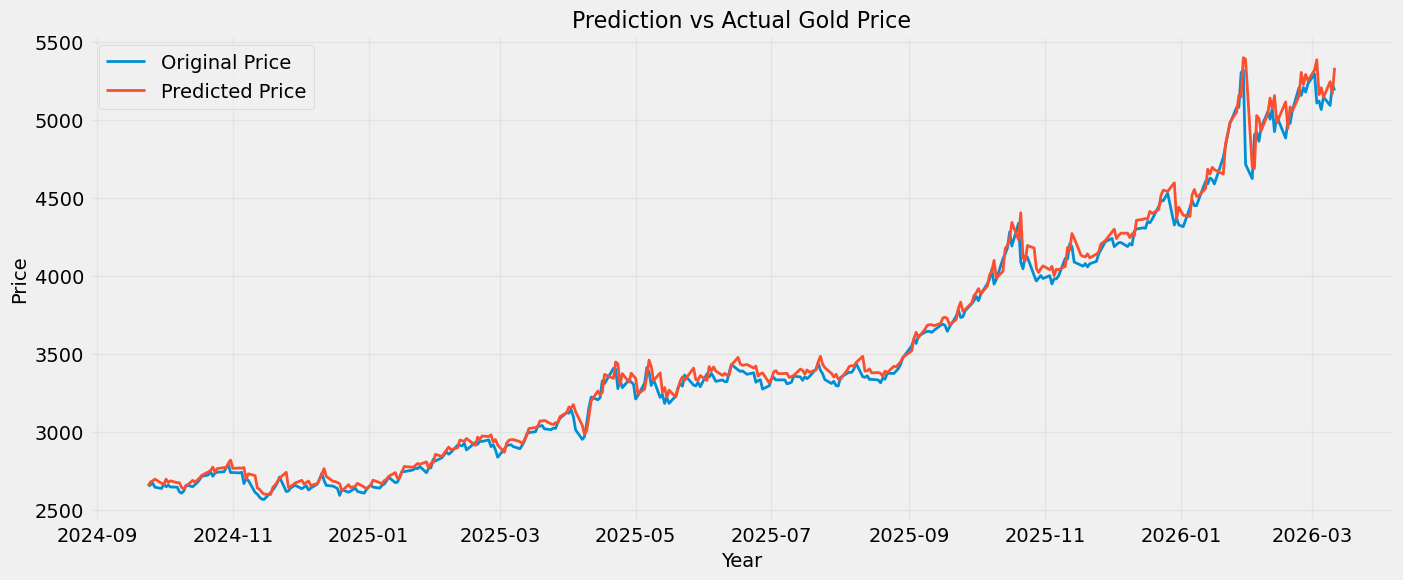

In [51]:
plotting_data = pd.DataFrame(
    {
        'Original': inverse_y_test.flatten(),
        'Prediction': inv_predictions.flatten(),
    },
    index = closing_price.index[train_size+base_days:]
)

plt.figure(figsize=(15,6))

plt.plot(plotting_data.index, plotting_data['Original'], label='Original Price', linewidth=2)
plt.plot(plotting_data.index, plotting_data['Prediction'], label='Predicted Price', linewidth=2)

plt.title("Prediction vs Actual Gold Price", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Price", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [52]:
last_100 = scaled_data[-100:].reshape(1,-1,1)

future_predictions = []

for _ in range(10):
    
    next_day = model.predict(last_100)
    
    future_predictions.append(scaler.inverse_transform(next_day))
    
    last_100 = np.append(last_100[:,1:,:], next_day.reshape(1,1,-1), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


In [53]:
future_predictions = np.array(future_predictions).flatten()

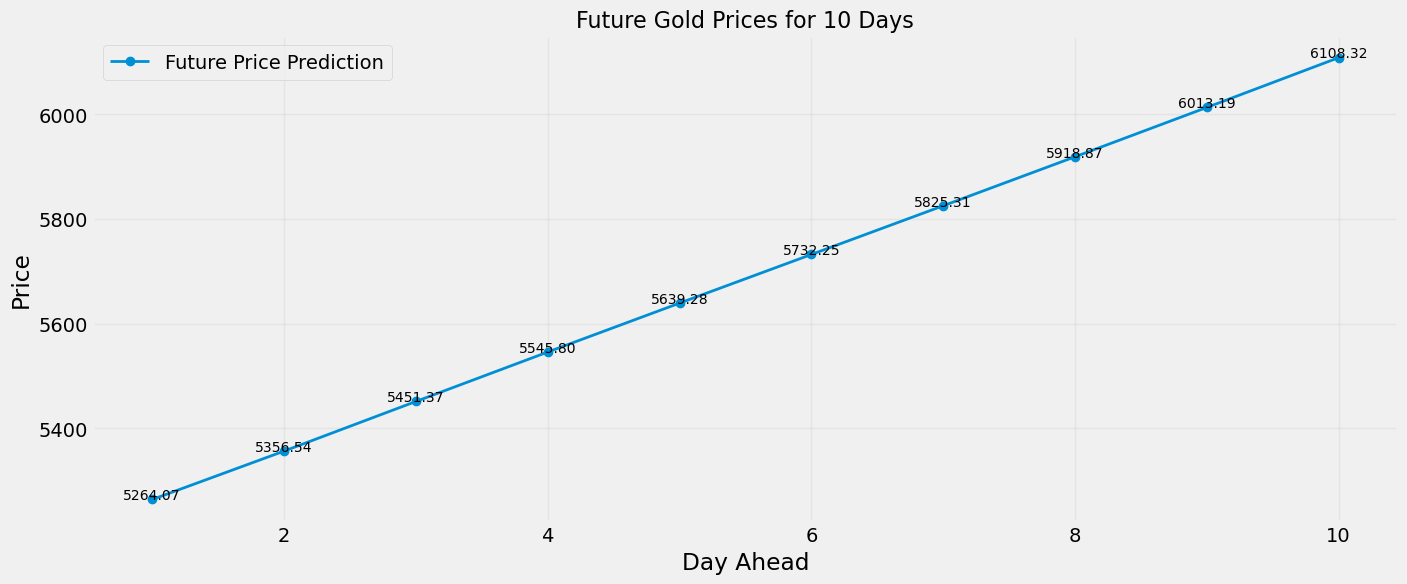

In [54]:
plt.figure(figsize=(15,6))

plt.plot(range(1,11), future_predictions, marker="o", label='Future Price Prediction', linewidth=2)

for i, val in enumerate(future_predictions):
    plt.text(i+1, val, f'{val:.2f}', fontsize=10, ha='center')

plt.title("Future Gold Prices for 10 Days", fontsize=16)
plt.xlabel("Day Ahead")
plt.ylabel("Price")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [55]:
model.save("gold_price_model.keras")

In [56]:
model.save("gold_price_model.h5")